# MediaPipe FaceMesh - ejemplo básico

Este notebook carga una imagen de muestra, detecta landmarks faciales con FaceMesh y los dibuja sobre la imagen.

La imagen de ejemplo está en `./data/sample_face.jpg`.

In [6]:
%matplotlib inline

from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np

NOTEBOOK_DATA = Path("008 - vision_artificial_aplicada/LAB/data/sample_face.jpg")
LOCAL_DATA = Path("./data/sample_face.jpg")
IMG_PATH = NOTEBOOK_DATA if NOTEBOOK_DATA.exists() else LOCAL_DATA

def show_bgr(image_bgr, title=None):
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 8))
    plt.imshow(image_rgb)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

def load_image(path: Path):
    if not path.exists():
        raise FileNotFoundError(
            f"No se encontró {path}. El notebook probablemente se ejecutó desde otra carpeta."
        )
    image = cv2.imread(str(path))
    if image is None:
        raise ValueError(f"No se pudo leer la imagen: {path}")
    return image


c:\Users\Cynthia\Desktop\ifts24-lab-pdi-2026-MATIAS\venv_facemesh\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


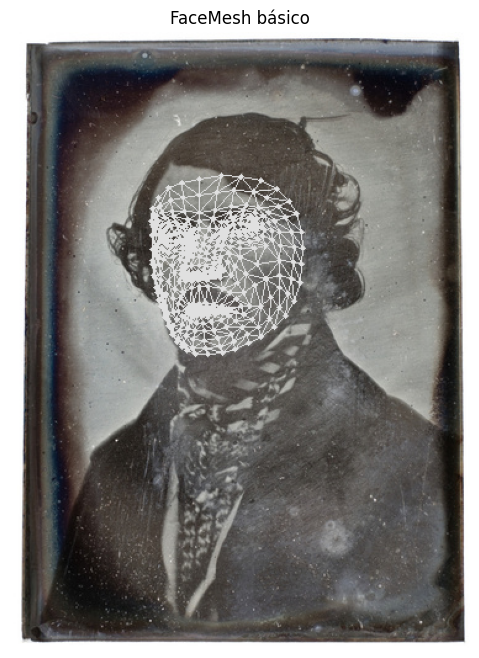

Landmarks detectados: 478
Primeros 5 puntos:
[[153 220]
 [148 195]
 [152 201]
 [146 178]
 [147 189]]


In [7]:
image_bgr = load_image(IMG_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
height, width, _ = image_bgr.shape

mp_face_mesh = mp.solutions.face_mesh
mp_drawing = mp.solutions.drawing_utils
drawing_spec = mp_drawing.DrawingSpec(thickness=1, circle_radius=1)

with mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
) as face_mesh:
    results = face_mesh.process(image_rgb)

if not results.multi_face_landmarks:
    print("No se detectó ningún rostro. Probá con otra imagen.")
else:
    annotated = image_bgr.copy()
    for face_landmarks in results.multi_face_landmarks:
        mp_drawing.draw_landmarks(
            image=annotated,
            landmark_list=face_landmarks,
            connections=mp_face_mesh.FACEMESH_TESSELATION,
            landmark_drawing_spec=drawing_spec,
            connection_drawing_spec=drawing_spec,
        )

    show_bgr(annotated, title="FaceMesh básico")
    
    keypoints = np.array([
        (int(lm.x * width), int(lm.y * height))
        for lm in results.multi_face_landmarks[0].landmark
    ])
    print(f"Landmarks detectados: {len(keypoints)}")
    print("Primeros 5 puntos:")
    print(keypoints[:5])
